In [1]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
import ast
import os

In [2]:
# Load ptb-xl dataset
path = '../ptb-xl'
df = pd.read_csv(os.path.join(path, 'ptbxl_database.csv'), index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Define target classes
target_classes = ['NORM', 'AFIB', '1AVB']

# Return target class label count
def get_label(scp_codes):
    matches = [label for label in target_classes if label in scp_codes]
    if len(matches) == 1:
        return matches[0]
    return None

df['label'] = df['scp_codes'].apply(get_label)
df = df[df['label'].notna()]

# Print label counts
print(df['label'].value_counts())

label
NORM    9439
AFIB    1468
1AVB     746
Name: count, dtype: int64


In [3]:
# Split data for train/validation/testing
train_df = df[df['strat_fold'] <= 8]
val_df = df[df['strat_fold'] == 9]
test_df = df[df['strat_fold'] == 10]

# Print data split values
print(f'Train: {len(train_df)}')
print(f'Validation: {len(val_df)}')
print(f'Test: {len(test_df)}')
print(f'\nTrain label distribution:\n{train_df["label"].value_counts()}')

Train: 9301
Validation: 1170
Test: 1182

Train label distribution:
label
NORM    7534
AFIB    1173
1AVB     594
Name: count, dtype: int64


In [4]:
# Verify raw sample signal
sample = train_df.iloc[0]
signal, fields = wfdb.rdsamp(os.path.join(path, sample['filename_lr']))
print(signal.shape)
print(fields['sig_name'])

(1000, 12)
['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [5]:
# Reduce dataset extracting only lead II at index 1
def load_signals(df, path):
    signals = []
    for _, row in df.iterrows():
        signal, _ = wfdb.rdsamp(os.path.join(path, str(row['filename_lr'])))
        lead_ii = signal[:, 1].reshape(-1, 1)
        signals.append(lead_ii)
    return np.array(signals)

# Load and print shapes of loaded signals
print('Loading training signals...')
X_train = load_signals(train_df, path)
print('Loading validation signals...')
X_val = load_signals(val_df, path)
print('Loading test signals...')
X_test = load_signals(test_df, path)

print(f'\nX_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'X_test shape: {X_test.shape}')

Loading training signals...
Loading validation signals...
Loading test signals...

X_train shape: (9301, 1000, 1)
X_val shape: (1170, 1000, 1)
X_test shape: (1182, 1000, 1)


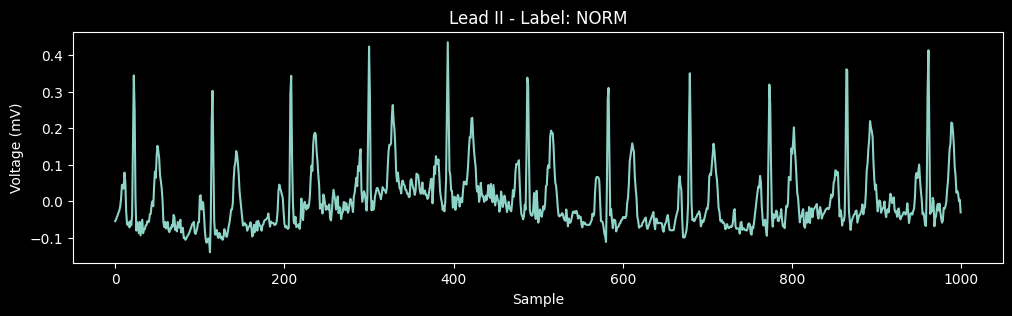

In [6]:
# Visualize raw sample signal before preprocessing
lead_ii = signal[:, 1]
plt.figure(figsize=(12, 3))
plt.plot(lead_ii)
plt.title(f'Lead II - Label: {sample["label"]}')
plt.xlabel('Sample')
plt.ylabel('Voltage (mV)')
plt.show()

In [7]:
# Normalize the dataset to ensure model accuracy is not affected by signal scale
def normalize(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    return (X - mean) / (std + 1e-8)

X_train = normalize(X_train)
X_val = normalize(X_val)
X_test = normalize(X_test)

print(f'Train mean: {X_train.mean():.4f}')
print(f'Train std: {X_train.std():.4f}')

Train mean: 0.0000
Train std: 1.0000


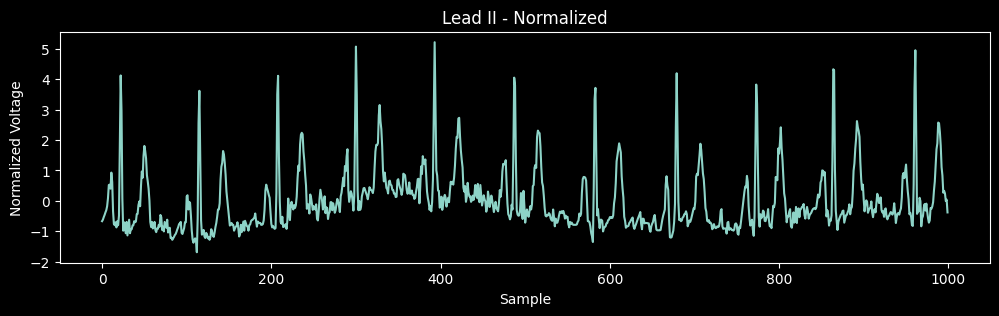

In [8]:
# Visualize sample signal after normalization
plt.figure(figsize=(12, 3))
plt.plot(X_train[0])
plt.title('Lead II - Normalized')
plt.xlabel('Sample')
plt.ylabel('Normalized Voltage')
plt.show()

In [9]:
# Encode the labels for training
le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_val = le.transform(val_df['label'])
y_test = le.transform(test_df['label'])

print(le.classes_)
print(y_train[:10])

['1AVB' 'AFIB' 'NORM']
[2 2 2 2 2 2 2 2 2 2]


In [10]:
# Transform data to one-hot format
y_train = tf.keras.utils.to_categorical(y_train, num_classes=len(le.classes_))
y_val = tf.keras.utils.to_categorical(y_val, num_classes=len(le.classes_))
y_test = tf.keras.utils.to_categorical(y_test, num_classes=len(le.classes_))

# Print shapes of transformed data
print(y_train.shape)
print(y_train[0])

(9301, 3)
[0. 0. 1.]


In [11]:
# Functions to normalize the dataset by creating synthetic samples
# Add Gaussian noise function
def add_gaussian(signal):
    signal += np.random.normal(0, 0.01, size=signal.shape)
    return signal

# Add amplitude scaling function
def add_amplitude_scaling(signal):
    signal = signal * np.random.uniform(0.9, 1.1)
    return signal

# Add time shift function
def add_time_shift(signal):
    signal = np.roll(signal, np.random.randint(0, 2500), axis=0)
    return signal

# Add baseline wander function
def add_baseline_wander(signal):
    signal += np.sin(np.linspace(0, np.random.uniform(0.1, 0.5), signal.shape[0]).reshape(-1, 1))
    return signal

# Create synthetic sample function
def create_sample(signal, counter):
    # Define augmentation combinations
    augmentations = [
    [add_gaussian],
    [add_amplitude_scaling],
    [add_time_shift],
    [add_baseline_wander],
    [add_gaussian, add_amplitude_scaling],
    [add_gaussian, add_time_shift],
    [add_gaussian, add_baseline_wander],
    [add_amplitude_scaling, add_time_shift],
    [add_amplitude_scaling, add_baseline_wander],
    [add_time_shift, add_baseline_wander],
    [add_gaussian, add_amplitude_scaling, add_time_shift],
    [add_gaussian, add_amplitude_scaling, add_baseline_wander],
    [add_gaussian, add_time_shift, add_baseline_wander],
    [add_amplitude_scaling, add_time_shift, add_baseline_wander],
    [add_gaussian, add_amplitude_scaling, add_time_shift, add_baseline_wander]
    ]

    for aug in augmentations[counter % len(augmentations)]:
        signal = aug(signal)

    return signal

In [12]:
# Separate classes that need to be augmented
classes_to_augment = [X_train[np.argmax(y_train, axis=1) == 0], X_train[np.argmax(y_train, axis=1) == 1]]

print(classes_to_augment[0].shape)
print(classes_to_augment[1].shape)

(594, 1000, 1)
(1173, 1000, 1)


In [13]:
# Create synthetic samples for each class
augmented_afib = []
augmented_1avb = []

avb_counter = 0
afib_counter = 0

while len(augmented_1avb) < 6900:
    current_sample = classes_to_augment[0][avb_counter % len(classes_to_augment[0])].copy()
    augmented_1avb.append(create_sample(current_sample, avb_counter))
    avb_counter += 1

while len(augmented_afib) < 6300:
    current_sample = classes_to_augment[1][afib_counter % len(classes_to_augment[1])].copy()
    augmented_afib.append(create_sample(current_sample, afib_counter))
    afib_counter += 1

print(len(augmented_1avb))
print(len(augmented_afib))

6900
6300


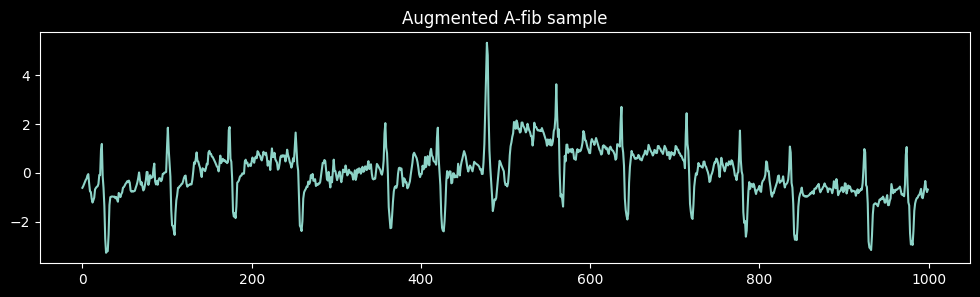

In [14]:
# Visualize sample signal after normalization
plt.figure(figsize=(12, 3))
plt.plot(augmented_afib[0])
plt.title('Augmented A-fib sample')
plt.show()

In [15]:
# Create labels for augmented samples
avb_labels = np.tile([1, 0, 0], (6900, 1))
afib_labels = np.tile([0, 1, 0], (6300, 1))

# Convert lists to arrays
augmented_1avb = np.array(augmented_1avb)
augmented_afib = np.array(augmented_afib)

# Concatenate augmented samples with original samples
X_train = np.concatenate([X_train, augmented_1avb, augmented_afib], axis=0)
y_train = np.concatenate([y_train, avb_labels, afib_labels], axis=0)

print(X_train.shape)
print(y_train.shape)

# Verify class distribution
print(np.sum(y_train, axis=0))

(22501, 1000, 1)
(22501, 3)
[7494. 7473. 7534.]


In [16]:
# Save augmented dataset to file
np.savez_compressed('../final_augmented_dataset.npz', X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)

# Verify file was saved successfully
print(os.path.exists('../final_augmented_dataset.npz'))

True
